# Model training 

Now that we have retrieved some past games data (1 season) and that we have all our features ready, we can build our classifier model.

- First we can try to use a logistic regression model to see even with a simple classifier if the performances are acceptable
- Then we could try with a RandomForestClassifier
- One other interesting model could be a simple Multi layer Perceptron (MLP)
- In a second time we could try to use an Autoregressive model such as an LSTM as they process timeseries natively

In [36]:
# Import the libraries needed
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import random
import requests
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
import plotly.graph_objects as go



## Data loading

In [5]:
# First we can load the dataframe already built 

df = pd.read_csv('/Users/macdebenji/Desktop/Projects/LiveWinningProbabilityTracker/data/processed/season23_24.csv')

## Model building 

In [8]:
SEED = 42

In [11]:
# We need to splitt the data first between train and test only using the GAME_ID so that one game is not in training and validation
game_ids = df['GAME_ID'].unique()
random.seed(SEED)
random.shuffle(game_ids)

# Then we can include 15% of the games in the test set
N_GAMES_TEST = int(0.15 * len(game_ids))

n_train_games = len(game_ids) - N_GAMES_TEST

train_games = game_ids[:n_train_games]
test_games = game_ids[n_train_games:]

df_train = df[df['GAME_ID'].isin(train_games)]
df_test = df[df['GAME_ID'].isin(test_games)]

# Print the shapes of the train and test dataframes
print(f"Training set shape : {df_train.shape}")
print(f"Test set shape : {df_test.shape}")


Training set shape : (431009, 6)
Test set shape : (75480, 6)


In [12]:
X_train = df_train.drop(['GAME_ID', 'home_win'], axis=1)
y_train = df_train['home_win'].values

X_test = df_test.drop(['GAME_ID', 'home_win'], axis=1)
y_test = df_test['home_win'].values

In [14]:
# Now we can train on the train set  
 
model = LogisticRegression()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

In [17]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

In [37]:
y_pred_proba_true = y_pred_proba[:,1]

In [52]:
print(classification_report(y_test, y_pred, target_names=["True", "False"]))

              precision    recall  f1-score   support

        True       0.58      0.85      0.69     30543
       False       0.85      0.57      0.68     44937

    accuracy                           0.69     75480
   macro avg       0.71      0.71      0.69     75480
weighted avg       0.74      0.69      0.69     75480



/Users/macdebenji/Desktop/Projects/LiveWinningProbabilityTracker/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/macdebenji/Desktop/Projects/LiveWinningProbabilityTracker/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


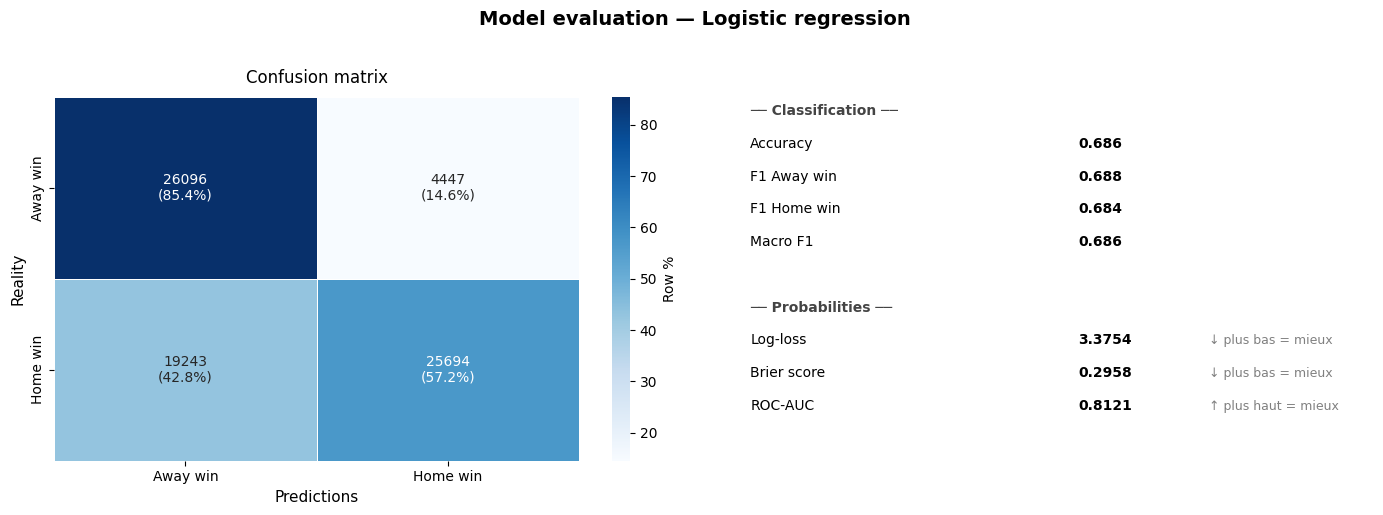

In [44]:
def plot_confusion_matrix(y_true, y_pred, y_proba):
    """
    Matrice de confusion enrichie :
    - valeurs absolues + pourcentages
    - métriques clés en dessous
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Model evaluation — Logistic regression", 
                 fontsize=14, fontweight='bold', y=1.02)

    # Confusion matrix
    ax = axes[0]
    labels = ["Away win", "Home win"]
    annot = np.array([
        [f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)]
        for i in range(2)
    ])
    sns.heatmap(
        cm_pct, annot=annot, fmt='', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Row %'}, ax=ax
    )
    ax.set_xlabel("Predictions", fontsize=11)
    ax.set_ylabel("Reality", fontsize=11)
    ax.set_title("Confusion matrix", fontsize=12, pad=10)

    # Text metrics
    ax2 = axes[1]
    ax2.axis('off')

    report = classification_report(y_true, y_pred,
                                   target_names=labels, output_dict=True)
    ll    = log_loss(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)
    auc   = roc_auc_score(y_true, y_proba)

    metrics = [
        ("── Classification ──", "", ""),
        ("Accuracy",     f"{report['accuracy']:.3f}", ""),
        ("F1 Away win",  f"{report['Away win']['f1-score']:.3f}", ""),
        ("F1 Home win",  f"{report['Home win']['f1-score']:.3f}", ""),
        ("Macro F1",     f"{report['macro avg']['f1-score']:.3f}", ""),
        ("", "", ""),
        ("── Probabilities ──", "", ""),
        ("Log-loss",     f"{ll:.4f}",    "↓ plus bas = mieux"),
        ("Brier score",  f"{brier:.4f}", "↓ plus bas = mieux"),
        ("ROC-AUC",      f"{auc:.4f}",   "↑ plus haut = mieux"),
    ]

    y_pos = 0.95
    for name, val, hint in metrics:
        if name.startswith("──"):
            ax2.text(0.05, y_pos, name, fontsize=10,
                     fontweight='bold', color='#444', transform=ax2.transAxes)
        else:
            ax2.text(0.05, y_pos, name,  fontsize=10, transform=ax2.transAxes)
            ax2.text(0.55, y_pos, val,   fontsize=10, fontweight='bold',
                     transform=ax2.transAxes)
            ax2.text(0.75, y_pos, hint,  fontsize=9,  color='gray',
                     transform=ax2.transAxes)
        y_pos -= 0.09

    plt.tight_layout()
    # plt.savefig('notebooks/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

# Appel
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_pred, y_proba)

In [49]:
# Create a column that is a global remaining time
random_game = test_games[0]

game_df = df_test[df_test['GAME_ID'] == random_game]

nb_quarter = game_df['quarter'].unique()[-1]

game_df["glo_time_remaining"] = (nb_quarter + 1 - game_df['quarter'])*game_df['time_remaining']

In [50]:
nb_quarter

np.int64(4)

In [51]:
# It could be very interesting to plot the evolution of the score diff colorated by the predicted proba along one game

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=game_df['glo_time_remaining'],
        y=game_df['score_diff'],
        mode='markers',
        
        marker=dict(
            size=8,
            color=y_pred_proba_true,     # couleur = probabilité
            colorscale='Viridis',   # dégradé
            colorbar=dict(
                title="Proba home win"
            ),
            showscale=True,
            opacity=0.8
        ),

        text=[
            f"Proba: {p:.3f}"
            for p in y_pred_proba_true
        ],

        hovertemplate=
            "time_remaining: %{x:.2f}<br>" +
            "score_diff: %{y:.2f}<br>" +
            "%{text}<extra></extra>"
    )
)

fig.update_layout(
    title="Evolution of the predicted proba along the game",
    template="plotly_white",
    width=900,
    height=700
)

fig.show()

In [43]:
game_df.shape

(356, 6)

In [41]:
y_pred_proba_true.shape

(75480,)

In [ ]:
# It is important to also plot a calibration curve when dealing with models that return probabilities